# Carga de Datos

In [34]:

import numpy as np 
import pandas as pd 
import scipy.stats as stats
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest # Prueba de z de proporcines 
from statsmodels.stats.multitest import multipletests #para corrección bonferroni

df = pd.read_excel("temperaturas.xlsx")
pd.set_option("display.max_rows", None)  # Mostrar todas las filas
pd.set_option("display.max_columns", None)  # Mostrar todas las columnas
print(df)

      T_Max3  T_atm  Humidity  aveOralM
0      35.48   24.0      28.0     36.59
1      35.14   24.0      26.0     37.19
2      35.75   24.0      26.0     37.34
3      35.77   24.0      27.0     37.09
4      35.72   24.0      27.0     37.04
5      35.76   24.0      26.0     36.99
6      35.64   24.0      31.0     36.59
7      35.71   25.0      30.0     36.49
8      35.76   25.0      30.0     36.59
9      36.21   26.0      31.0     36.89
10     35.64   22.8      15.5     36.54
11     35.87   23.0      14.0     36.74
12     35.80   23.0      14.0     36.54
13     36.00   23.0      14.0     37.19
14     36.91   23.5      53.0     37.79
15     35.68   23.7      61.2     36.49
16     35.82   24.0      61.0     37.09
17     36.37   22.5      23.1     37.19
18     35.92   23.2      22.6     36.89
19     35.71   22.6      22.6     36.54
20     35.60   22.9      22.7     37.04
21     35.89   23.0      22.4     37.04
22       NaN   23.1      22.8     36.14
23     35.67   23.1      22.7     36.99


# Análisis Exploratorio

Iniciamos llenando los datos faltantes

In [35]:
df["T_Max3"] = df["T_Max3"].fillna(df["T_Max3"].mean())
df["T_atm"] = df["T_atm"].fillna(df["T_atm"].mean())
df["Humidity"] = df["Humidity"].fillna(df["Humidity"].mean())
df["aveOralM"] = df["aveOralM"].fillna(df["aveOralM"].mean())

Ahora hacemos un gráfico de cajas y bigotes para ver su media, Datos atipicos y percentiles Q1,Q2 y Q3; de T_Max3 y aveOralM devido a que estas son las variables que debemos verificar si fueron correctamente medidas.

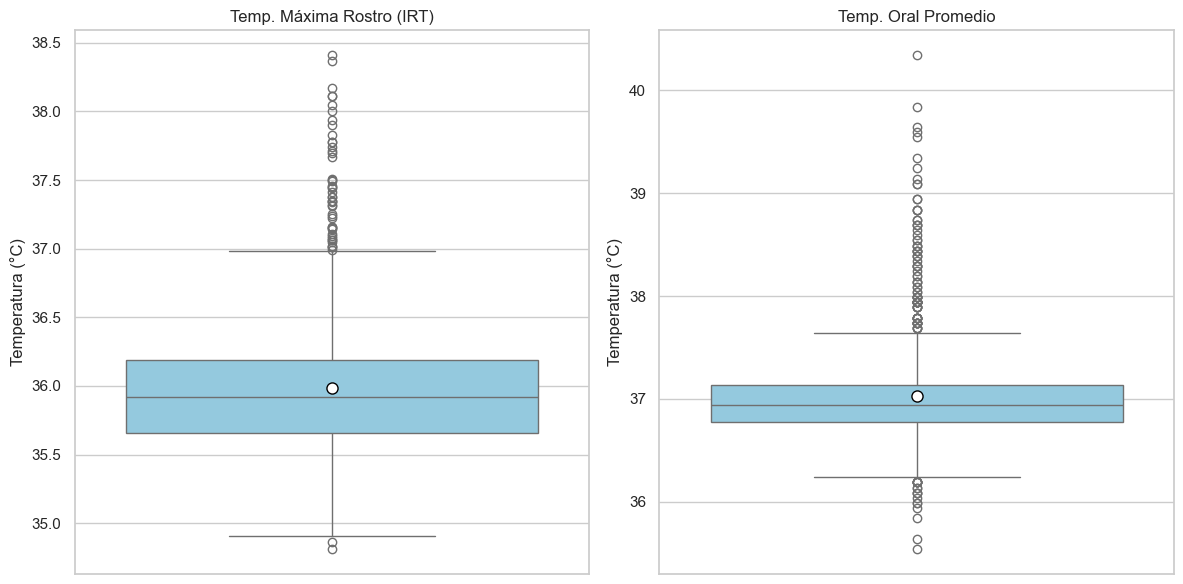


Estadísticas para T_Max3:
Media (punto blanco): 35.98
Q1 (25%): 35.66
Q2/Mediana (50%): 35.92
Q3 (75%): 36.19

Estadísticas para aveOralM:
Media (punto blanco): 37.03
Q1 (25%): 36.78
Q2/Mediana (50%): 36.94
Q3 (75%): 37.14


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos para comparar ambas variables
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Lista de las variables a graficar
variables = ['T_Max3', 'aveOralM']
titulos = ['Temp. Máxima Rostro (IRT)', 'Temp. Oral Promedio']

for i, col in enumerate(variables):
    # showmeans=True añade un marcador para la media aritmética
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue", showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
    
    axes[i].set_title(titulos[i])
    axes[i].set_ylabel('Temperatura (°C)')

plt.tight_layout()
plt.show()

# Código opcional para imprimir los valores numéricos exactos de los percentiles
for col in variables:
    stats = df[col].describe()
    print(f"\nEstadísticas para {col}:")
    print(f"Media (punto blanco): {stats['mean']:.2f}")
    print(f"Q1 (25%): {stats['25%']:.2f}")
    print(f"Q2/Mediana (50%): {stats['50%']:.2f}")
    print(f"Q3 (75%): {stats['75%']:.2f}")
    # Los puntos fuera de los 'bigotes' son los datos atípicos

Ahora calculamos la diferencia entre T_Max3 y aveOralM para verificar cuales datos son verdaderamente atípicos

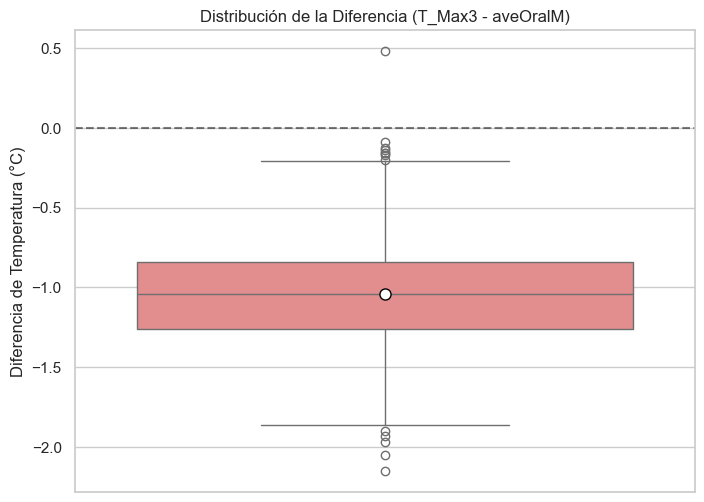

--- Estadísticas de la Diferencia ---
Media (punto blanco): -1.044 °C
Percentil Q1 (25%): -1.263 °C
Percentil Q2/Mediana (50%): -1.040 °C
Percentil Q3 (75%): -0.840 °C
Total de datos atípicos detectados: 13


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la diferencia (Error de medición)
# Se resta la temperatura oral (referencia) de la temperatura facial
df['Diferencia'] = df['T_Max3'] - df['aveOralM']

# 2. Configuración del gráfico
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Crear el gráfico de cajas y bigotes para la diferencia
# showmeans=True permite visualizar la media aritmética
sns.boxplot(y=df['Diferencia'], color="lightcoral", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Distribución de la Diferencia (T_Max3 - aveOralM)')
plt.ylabel('Diferencia de Temperatura (°C)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de referencia en 0
plt.show()

# 3. Cálculo de estadísticas descriptivas detalladas
stats_diff = df['Diferencia'].describe()
q1 = df['Diferencia'].quantile(0.25)
q2 = df['Diferencia'].quantile(0.50)
q3 = df['Diferencia'].quantile(0.75)
iqr = q3 - q1

# Identificación de datos atípicos (Outliers) usando el método de IQR
atipicos_bajo = df[df['Diferencia'] < (q1 - 1.5 * iqr)]['Diferencia'].count()
atipicos_alto = df[df['Diferencia'] > (q3 + 1.5 * iqr)]['Diferencia'].count()

print("--- Estadísticas de la Diferencia ---")
print(f"Media (punto blanco): {stats_diff['mean']:.3f} °C")
print(f"Percentil Q1 (25%): {q1:.3f} °C")
print(f"Percentil Q2/Mediana (50%): {q2:.3f} °C")
print(f"Percentil Q3 (75%): {q3:.3f} °C")
print(f"Total de datos atípicos detectados: {atipicos_bajo + atipicos_alto}")

Ahora quitamos los datos verdaderamente atípicos en las columnas de T_Max3 y aveOralM

In [38]:
# 1. Calcular Q1, Q3 e IQR para la columna 'Diferencia'
Q1 = df['Diferencia'].quantile(0.25)
Q3 = df['Diferencia'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir los límites para identificar atípicos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 3. Identificar las filas que contienen datos atípicos
filas_atipicas = df[(df['Diferencia'] < limite_inferior) | (df['Diferencia'] > limite_superior)]

print(f"Se encontraron {len(filas_atipicas)} filas con datos atípicos en la diferencia.")
print("Índices de las filas a eliminar:", filas_atipicas.index.tolist())

# 4. Eliminar estas filas de la base de datos original
df_limpio = df.drop(filas_atipicas.index)

print(f"\nDimensiones originales: {df.shape}")
print(f"Dimensiones después de eliminar atípicos: {df_limpio.shape}")

# Opcional: Si quieres sobreescribir el dataframe original para los siguientes pasos del taller:
# df = df_limpio

Se encontraron 13 filas con datos atípicos en la diferencia.
Índices de las filas a eliminar: [1, 22, 122, 150, 329, 514, 591, 636, 645, 674, 741, 845, 957]

Dimensiones originales: (1020, 5)
Dimensiones después de eliminar atípicos: (1007, 5)


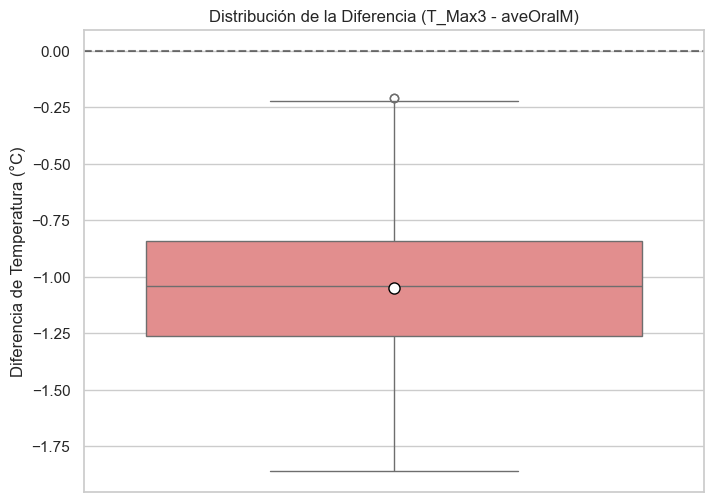

--- Estadísticas de la Diferencia ---
Media (punto blanco): -1.047 °C
Percentil Q1 (25%): -1.260 °C
Percentil Q2/Mediana (50%): -1.040 °C
Percentil Q3 (75%): -0.840 °C
Total de datos atípicos detectados: 2


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la diferencia (Error de medición)
# Se resta la temperatura oral (referencia) de la temperatura facial
df_limpio['Diferencia'] = df_limpio['T_Max3'] - df_limpio['aveOralM']

# 2. Configuración del gráfico
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Crear el gráfico de cajas y bigotes para la diferencia
# showmeans=True permite visualizar la media aritmética
sns.boxplot(y=df_limpio['Diferencia'], color="lightcoral", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Distribución de la Diferencia (T_Max3 - aveOralM)')
plt.ylabel('Diferencia de Temperatura (°C)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de referencia en 0
plt.show()

# 3. Cálculo de estadísticas descriptivas detalladas
stats_diff = df_limpio['Diferencia'].describe()
q1 = df_limpio['Diferencia'].quantile(0.25)
q2 = df_limpio['Diferencia'].quantile(0.50)
q3 = df_limpio['Diferencia'].quantile(0.75)
iqr = q3 - q1

# Identificación de datos atípicos (Outliers) usando el método de IQR
atipicos_bajo = df_limpio[df_limpio['Diferencia'] < (q1 - 1.5 * iqr)]['Diferencia'].count()
atipicos_alto = df_limpio[df_limpio['Diferencia'] > (q3 + 1.5 * iqr)]['Diferencia'].count()
print("--- Estadísticas de la Diferencia ---")
print(f"Media (punto blanco): {stats_diff['mean']:.3f} °C")
print(f"Percentil Q1 (25%): {q1:.3f} °C")
print(f"Percentil Q2/Mediana (50%): {q2:.3f} °C")
print(f"Percentil Q3 (75%): {q3:.3f} °C")
print(f"Total de datos atípicos detectados: {atipicos_bajo + atipicos_alto}")

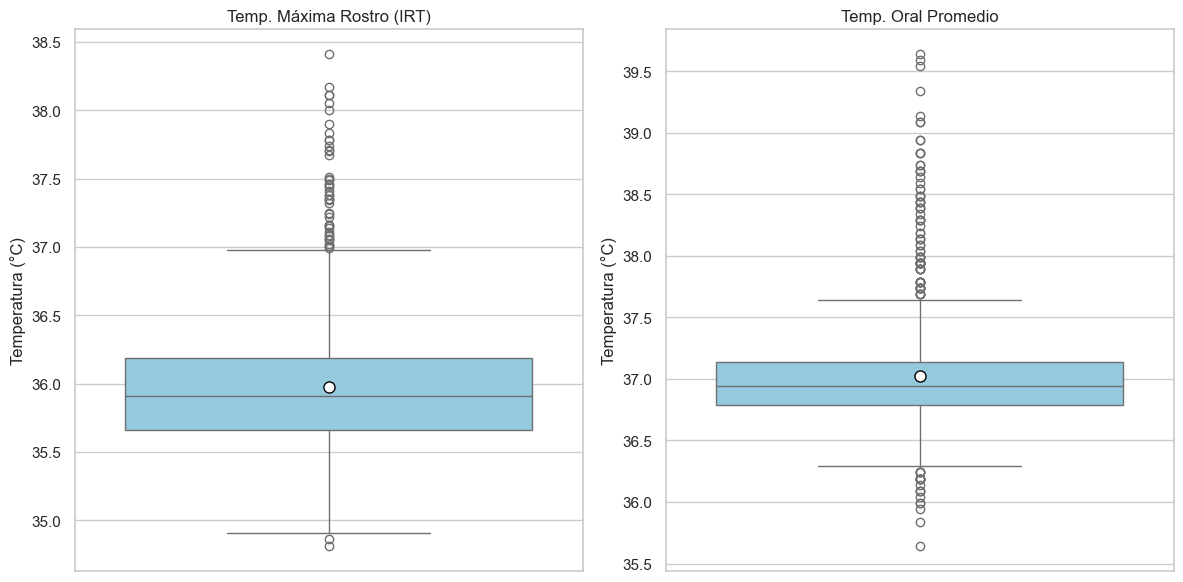


Estadísticas para T_Max3:
Media (punto blanco): 35.98
Q1 (25%): 35.66
Q2/Mediana (50%): 35.91
Q3 (75%): 36.19

Estadísticas para aveOralM:
Media (punto blanco): 37.02
Q1 (25%): 36.79
Q2/Mediana (50%): 36.94
Q3 (75%): 37.14


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos para comparar ambas variables
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Lista de las variables a graficar
variables = ['T_Max3', 'aveOralM']
titulos = ['Temp. Máxima Rostro (IRT)', 'Temp. Oral Promedio']

for i, col in enumerate(variables):
    # showmeans=True añade un marcador para la media aritmética
    sns.boxplot(y=df_limpio[col], ax=axes[i], color="skyblue", showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
    
    axes[i].set_title(titulos[i])
    axes[i].set_ylabel('Temperatura (°C)')

plt.tight_layout()
plt.show()

# Código opcional para imprimir los valores numéricos exactos de los percentiles
for col in variables:
    stats = df_limpio[col].describe()
    print(f"\nEstadísticas para {col}:")
    print(f"Media (punto blanco): {stats['mean']:.2f}")
    print(f"Q1 (25%): {stats['25%']:.2f}")
    print(f"Q2/Mediana (50%): {stats['50%']:.2f}")
    print(f"Q3 (75%): {stats['75%']:.2f}")
    # Los puntos fuera de los 'bigotes' son los datos atípicos

In [42]:
# 1. Asegurarse de tener la librería necesaria (ejecutar en una celda si no la tienes)
# !pip install openpyxl

# 2. Guardar el DataFrame limpio en un archivo .xlsx
# Usamos index=False para que no se guarde la columna de índices de filas en el Excel
df_limpio.to_excel('Datos_EBT_Limpios.xlsx', index=False)

print("El archivo 'Datos_EBT_Limpios.xlsx' ha sido guardado exitosamente.")

El archivo 'Datos_EBT_Limpios.xlsx' ha sido guardado exitosamente.


Ahora realizamos la matriz de correlación

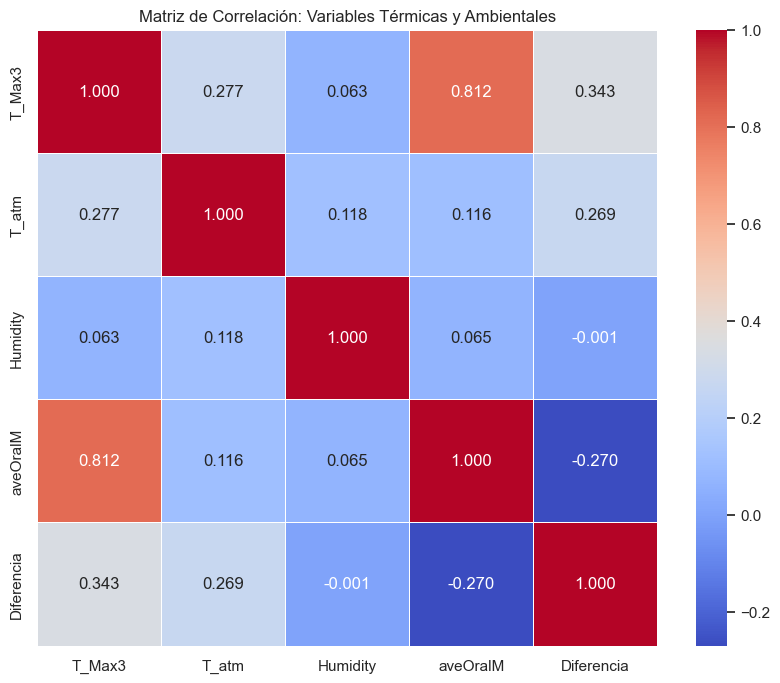

--- Correlación con la Temperatura Oral (aveOralM) ---
aveOralM      1.000000
T_Max3        0.811956
T_atm         0.116098
Humidity      0.065056
Diferencia   -0.270306
Name: aveOralM, dtype: float64


In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el archivo con los datos limpios
# Asegúrate de que el nombre coincida con el archivo guardado anteriormente
df_final = pd.read_excel('Datos_EBT_Limpios.xlsx')

# 2. Calcular la matriz de correlación
# Usamos el método de Pearson por defecto para buscar relaciones lineales
matriz_corr = df_final.corr()

# 3. Graficar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Generar un mapa de calor
sns.heatmap(matriz_corr, 
            annot=True,          # Muestra los valores numéricos
            cmap='coolwarm',     # Escala de colores (rojo positivo, azul negativo)
            fmt=".3f",           # Tres decimales para mayor precisión
            linewidths=0.5)

plt.title('Matriz de Correlación: Variables Térmicas y Ambientales')
plt.show()

# 4. Mostrar específicamente la correlación con la variable respuesta
print("--- Correlación con la Temperatura Oral (aveOralM) ---")
print(matriz_corr['aveOralM'].sort_values(ascending=False))

Vemos que la mayor correlación se da entre T_Max3 y aveOralM, debido a que son variables dependiente a causa de que se midieron en la misma persona.

# Modelo de Regresión Lineal Múltiple de Efectos Principales,  

In [44]:
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Cargar los datos limpios
df_final = pd.read_excel('Datos_EBT_Limpios.xlsx')

# 2. Definir variables predictoras (Efectos Principales) y variable respuesta
X = df_final[['T_Max3', 'T_atm', 'Humidity']]
y = df_final['aveOralM']

# 3. Construcción del modelo con Scikit-Learn (para predicciones rápidas)
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

# 4. Construcción del modelo con Statsmodels (para obtener el resumen estadístico detallado)
X_con_constante = sm.add_constant(X) # Añadir intercepto
modelo_stats = sm.OLS(y, X_con_constante).fit()

# 5. Visualización de resultados
print("--- Resumen del Modelo de Efectos Principales ---")
print(modelo_stats.summary())

# Predicciones y métricas básicas en el conjunto de entrenamiento
y_pred = modelo_lineal.predict(X)
print(f"\nCoeficiente de Determinación (R2): {r2_score(y, y_pred):.4f}")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y, y_pred):.4f}")

--- Resumen del Modelo de Efectos Principales ---
                            OLS Regression Results                            
Dep. Variable:               aveOralM   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     687.2
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          1.15e-242
Time:                        13:52:30   Log-Likelihood:                -135.78
No. Observations:                1007   AIC:                             279.6
Df Residuals:                    1003   BIC:                             299.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co